# Data Mining_2_Module_3
## 04 — Time-Series Classification & Shapelets

### Leakage control
The train/test split is performed **by participant ID** before supervised modelling:
- 70% participant IDs → train;
- 30% participant IDs → test;
- no participant appears in both sets.

Any scaling used by a final supervised model is fitted on training data only.  
For KNN model selection, scaling is fitted again inside each cross-validation fold.

### Final methods executed
1. KNN — Euclidean;
2. KNN — Manhattan;
3. KNN — DTW after PAA 200→50;
4. MiniROCKET — 10,000 kernels;
5. univariate ShapeletTransformClassifier on `enmo` — max 10;
6. RandomShapeletTransform + Logistic Regression on `enmo` — **max 100**;
7. multivariate ShapeletTransformClassifier after PAA 50 — max 10.

The discarded 100k-MiniROCKET, standard ROCKET and non-selected shapelet configurations are retained only as historical benchmarks, not rerun.

In [1]:
from pathlib import Path
import warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
]

def is_project_dir(path):
    return path.exists() and (
        (path / "data").exists()
        or (path / "artifacts").exists()
        or any(path.glob("CMI_timeseries_dataset*.pkl"))
    )

PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if is_project_dir(p)), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_CANDIDATES with your local project path."
    )

TS_PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "timeseries"
MODULE3_DIR = PROJECT_DIR / "artifacts" / "module3"

TS_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODULE3_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed time-series directory:", TS_PROCESSED_DIR)
print("Module 3 artifacts:", MODULE3_DIR)

Project directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2
Processed time-series directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/timeseries
Module 3 artifacts: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module3


In [2]:
import os
for variable in [
    "OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS","NUMEXPR_NUM_THREADS"
]:
    os.environ[variable] = "1"

INPUT_PATH = TS_PROCESSED_DIR / "CMI_timeseries_dataset_preproc.pkl"
if not INPUT_PATH.exists():
    raise FileNotFoundError("Run notebook 01 first: " + str(INPUT_PATH))

df = pd.read_pickle(INPUT_PATH)
CLASS_DIR = MODULE3_DIR / "classification"
CLASS_DIR.mkdir(parents=True, exist_ok=True)

print("Loaded:",INPUT_PATH)
print("Time series:",len(df))

Loaded: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/timeseries/CMI_timeseries_dataset_preproc.pkl
Time series: 4258


## 1. Dependency check

In [3]:
%pip install tslearn sktime tsfresh


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
try:
    import sktime
    import tslearn
except ImportError as exc:
    raise ImportError(
        "This notebook requires sktime and tslearn. Install them in the active environment, restart the kernel, then rerun."
    ) from exc

print("sktime:", sktime.__version__)
print("tslearn:", tslearn.__version__)

sktime: 1.2.0
tslearn: 0.9.0


## 2. Participant-level train/test split

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

signal_cols = ["X","Y","Z","enmo","light"]
id_col = "id"
target_col = "sii_binary"

X = np.array([ts[signal_cols].values for ts in df])
y = np.array([ts[target_col].iloc[0] for ts in df]).astype(int)
ids = np.array([ts[id_col].iloc[0] for ts in df])

id_target_df = pd.DataFrame({"id":ids,"sii_binary":y})
bad_ids = id_target_df.groupby("id")["sii_binary"].nunique()
if (bad_ids > 1).any():
    raise ValueError("At least one participant has inconsistent target values.")

id_level = id_target_df.drop_duplicates("id").reset_index(drop=True)
train_ids, test_ids = train_test_split(
    id_level["id"].to_numpy(),
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=id_level["sii_binary"].to_numpy(),
)

train_mask = np.isin(ids,train_ids)
test_mask = np.isin(ids,test_ids)
train_global_indices = np.flatnonzero(train_mask)
test_global_indices = np.flatnonzero(test_mask)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
ids_train, ids_test = ids[train_mask], ids[test_mask]

print("Train IDs:",len(train_ids),"Test IDs:",len(test_ids))
print("X_train:",X_train.shape,"X_test:",X_test.shape)
print("ID overlap:",len(set(ids_train).intersection(set(ids_test))))
print("Train target:",pd.Series(y_train).value_counts().sort_index().to_dict())
print("Test target:",pd.Series(y_test).value_counts().sort_index().to_dict())

assert len(set(ids_train).intersection(set(ids_test))) == 0

Train IDs: 228 Test IDs: 98
X_train: (3106, 200, 5) X_test: (1152, 200, 5)
ID overlap: 0
Train target: {0: 2035, 1: 1071}
Test target: {0: 820, 1: 332}


## 3. KNN — Euclidean and Manhattan

In [6]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# KNN CLASSIFICATION: GRID SEARCH
# DISTANCE: EUCLIDEAN / MANHATTAN
# WEIGHTS: UNIFORM / DISTANCE
# K: ODD VALUES UP TO sqrt(number of training time series)
# ============================================================

print("=" * 80)
print("KNN - GRID SEARCH: EUCLIDEAN / MANHATTAN + UNIFORM / DISTANCE")
print("=" * 80)

RANDOM_STATE = 42

# ============================================================
# 1. Definizione data-driven del range di k
# ============================================================

n_train_samples = X_train.shape[0]
n_train_ids = pd.Series(ids_train).nunique()

max_k = int(np.sqrt(n_train_samples))

# Per classificazione binaria preferiamo valori dispari per ridurre i pareggi
if max_k % 2 == 0:
    max_k -= 1

# Sicurezza nel caso di dataset molto piccolo
max_k = max(1, max_k)

k_values = list(range(1, max_k + 1, 2))

print("\nNumero ID nel train:")
print(n_train_ids)

print("\nValori di k testati:")
print(k_values)

# ============================================================
# 2. Griglia di iperparametri
# ============================================================

distance_metrics = ["euclidean", "manhattan"]
weight_options = ["uniform", "distance"]

print("\nDistanze testate:")
print(distance_metrics)

print("\nPesi dei vicini testati:")
print(weight_options)

# ============================================================
# 3. Definizione cross-validation stratificata per gruppi
# ============================================================

# Controllo distribuzione classi a livello ID nel train
id_train_df = pd.DataFrame({
    "id": ids_train,
    "target": y_train
}).drop_duplicates("id")

class_counts_id = id_train_df["target"].value_counts().sort_index()

print("\nDistribuzione classi a livello ID nel train:")
print(class_counts_id)

# Uso al massimo 5 fold, ma non più del numero minimo di ID nella classe minoritaria
min_class_count = class_counts_id.min()
n_splits = min(5, min_class_count)

if n_splits < 2:
    raise ValueError(
        "Non ci sono abbastanza ID nella classe minoritaria per fare cross-validation stratificata."
    )

print(f"\nNumero fold usati per la cross-validation: {n_splits}")

cv = StratifiedGroupKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Numero di canali della time series
n_channels = X_train.shape[2]

# ============================================================
# 4. Funzioni di utilità
# ============================================================

def scale_with_train_fold(X_fold_train, X_fold_val):
    """
    Fit dello StandardScaler solo sul fold di train.
    Transform sia del fold di train sia del fold di validation.
    Poi flatten 3D -> 2D per usare KNN.
    """

    scaler = StandardScaler()

    scaler.fit(
        X_fold_train.reshape(-1, n_channels)
    )

    X_fold_train_scaled = scaler.transform(
        X_fold_train.reshape(-1, n_channels)
    ).reshape(X_fold_train.shape)

    X_fold_val_scaled = scaler.transform(
        X_fold_val.reshape(-1, n_channels)
    ).reshape(X_fold_val.shape)

    X_fold_train_flat = X_fold_train_scaled.reshape(
        X_fold_train_scaled.shape[0],
        -1
    )

    X_fold_val_flat = X_fold_val_scaled.reshape(
        X_fold_val_scaled.shape[0],
        -1
    )

    return X_fold_train_flat, X_fold_val_flat


def compute_binary_metrics(y_true, y_pred):
    """
    Calcola metriche principali.
    Macro F1 viene usata per selezionare il modello,
    perché il target è sbilanciato.
    """

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

# ============================================================
# 5. Cross-validation grid search sul train
# ============================================================

results = []

for distance_metric in distance_metrics:

    for weight_option in weight_options:

        for k in k_values:

            fold_accuracy = []
            fold_precision_macro = []
            fold_recall_macro = []
            fold_f1_macro = []
            fold_f1_weighted = []

            print(
                f"\nRunning CV - distance={distance_metric}, "
                f"weights={weight_option}, k={k}"
            )

            for fold, (tr_idx, val_idx) in enumerate(
                cv.split(X_train, y_train, groups=ids_train),
                start=1
            ):

                X_fold_train = X_train[tr_idx]
                X_fold_val = X_train[val_idx]

                y_fold_train = y_train[tr_idx]
                y_fold_val = y_train[val_idx]

                # ------------------------------------------------
                # Scaling corretto dentro il fold
                # ------------------------------------------------

                X_fold_train_flat, X_fold_val_flat = scale_with_train_fold(
                    X_fold_train,
                    X_fold_val
                )

                # ------------------------------------------------
                # KNN
                # ------------------------------------------------

                knn = KNeighborsClassifier(
                    n_neighbors=k,
                    metric=distance_metric,
                    weights=weight_option
                )

                knn.fit(X_fold_train_flat, y_fold_train)

                y_fold_pred = knn.predict(X_fold_val_flat)

                fold_metrics = compute_binary_metrics(
                    y_fold_val,
                    y_fold_pred
                )

                fold_accuracy.append(fold_metrics["accuracy"])
                fold_precision_macro.append(fold_metrics["precision_macro"])
                fold_recall_macro.append(fold_metrics["recall_macro"])
                fold_f1_macro.append(fold_metrics["f1_macro"])
                fold_f1_weighted.append(fold_metrics["f1_weighted"])

            results.append({
                "distance": distance_metric,
                "weights": weight_option,
                "k": k,

                "cv_accuracy_mean": np.mean(fold_accuracy),
                "cv_accuracy_std": np.std(fold_accuracy),

                "cv_precision_macro_mean": np.mean(fold_precision_macro),
                "cv_precision_macro_std": np.std(fold_precision_macro),

                "cv_recall_macro_mean": np.mean(fold_recall_macro),
                "cv_recall_macro_std": np.std(fold_recall_macro),

                "cv_f1_macro_mean": np.mean(fold_f1_macro),
                "cv_f1_macro_std": np.std(fold_f1_macro),

                "cv_f1_weighted_mean": np.mean(fold_f1_weighted),
                "cv_f1_weighted_std": np.std(fold_f1_weighted)
            })

results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("RISULTATI CROSS-VALIDATION - GRID SEARCH")
print("=" * 80)

display(
    results_df
    .sort_values(
        ["cv_f1_macro_mean", "cv_f1_macro_std", "cv_accuracy_mean"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

# ============================================================
# 6. Migliore configurazione complessiva
# ============================================================

best_overall = (
    results_df
    .sort_values(
        ["cv_f1_macro_mean", "cv_f1_macro_std", "cv_accuracy_mean"],
        ascending=[False, True, False]
    )
    .head(1)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("MIGLIORE CONFIGURAZIONE COMPLESSIVA")
print("=" * 80)

display(best_overall)

# ============================================================
# 7. Migliore configurazione per ciascuna distanza
# ============================================================

# Questa tabella serve perché il progetto richiede di confrontare
# almeno due distanze: Euclidean/Manhattan e DTW successivamente.
# Qui confrontiamo Euclidean e Manhattan.

best_by_distance = (
    results_df
    .sort_values(
        ["distance", "cv_f1_macro_mean", "cv_f1_macro_std", "cv_accuracy_mean"],
        ascending=[True, False, True, False]
    )
    .groupby("distance")
    .head(1)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("MIGLIORE CONFIGURAZIONE PER CIASCUNA DISTANZA")
print("=" * 80)

display(best_by_distance)

# ============================================================
# 8. Test finale
# ============================================================

print("\n" + "=" * 80)
print("TEST FINALE")
print("=" * 80)

# Scaling finale:
# fit su tutto il train, transform su train e test
final_scaler = StandardScaler()

final_scaler.fit(
    X_train.reshape(-1, n_channels)
)

X_train_scaled_final = final_scaler.transform(
    X_train.reshape(-1, n_channels)
).reshape(X_train.shape)

X_test_scaled_final = final_scaler.transform(
    X_test.reshape(-1, n_channels)
).reshape(X_test.shape)

# Flatten 3D -> 2D per KNN
X_train_flat_final = X_train_scaled_final.reshape(
    X_train_scaled_final.shape[0],
    -1
)

X_test_flat_final = X_test_scaled_final.reshape(
    X_test_scaled_final.shape[0],
    -1
)

test_results = []

for _, row in best_by_distance.iterrows():

    distance_metric = row["distance"]
    weight_option = row["weights"]
    best_k = int(row["k"])

    knn_final = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=distance_metric,
        weights=weight_option
    )

    knn_final.fit(X_train_flat_final, y_train)

    y_test_pred = knn_final.predict(X_test_flat_final)

    test_metrics = compute_binary_metrics(
        y_test,
        y_test_pred
    )

    test_results.append({
        "model": f"KNN_{distance_metric}_{weight_option}",
        "distance": distance_metric,
        "weights": weight_option,
        "k": best_k,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
        "test_f1_weighted": test_metrics["f1_weighted"]
    })

    print("\n" + "=" * 80)
    print(
        f"KNN {distance_metric.upper()} | "
        f"weights={weight_option} | k={best_k}"
    )
    print("=" * 80)

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_test_pred,
            zero_division=0
        )
    )

    print("Confusion matrix:")

    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["true_0", "true_1"],
        columns=["pred_0", "pred_1"]
    )

    display(cm_df)

# ============================================================
# 9. Tabella finale confronto KNN
# ============================================================

test_results_df = pd.DataFrame(test_results)

print("\n" + "=" * 80)
print("CONFRONTO FINALE KNN - EUCLIDEAN VS MANHATTAN")
print("=" * 80)

display(test_results_df)

print("\nOggetti creati:")
print("results_df")
print("best_overall")
print("best_by_distance")
print("test_results_df")
print("final_scaler")

KNN - GRID SEARCH: EUCLIDEAN / MANHATTAN + UNIFORM / DISTANCE

Numero ID nel train:
228

Valori di k testati:
[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55]

Distanze testate:
['euclidean', 'manhattan']

Pesi dei vicini testati:
['uniform', 'distance']

Distribuzione classi a livello ID nel train:
target
0    144
1     84
Name: count, dtype: int64

Numero fold usati per la cross-validation: 5

Running CV - distance=euclidean, weights=uniform, k=1

Running CV - distance=euclidean, weights=uniform, k=3

Running CV - distance=euclidean, weights=uniform, k=5

Running CV - distance=euclidean, weights=uniform, k=7

Running CV - distance=euclidean, weights=uniform, k=9

Running CV - distance=euclidean, weights=uniform, k=11

Running CV - distance=euclidean, weights=uniform, k=13

Running CV - distance=euclidean, weights=uniform, k=15

Running CV - distance=euclidean, weights=uniform, k=17

Running CV - distance=euclidean, weights=un

,distance,weights,k,cv_accuracy_mean,cv_accuracy_std,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std
0,euclidean,uniform,3,0.580797,0.042274,0.515431,0.039383,0.510717,0.034418,0.507251,0.033804,0.565770,0.034433
1,euclidean,distance,3,0.580797,0.042274,0.515431,0.039383,0.510717,0.034418,0.507251,0.033804,0.565770,0.034433
2,manhattan,uniform,3,0.577579,0.029669,0.511758,0.019034,0.508699,0.016169,0.504535,0.014306,0.562831,0.018512
3,manhattan,distance,3,0.577579,0.029669,0.511758,0.019034,0.508699,0.016169,0.504535,0.014306,0.562831,0.018512
4,euclidean,uniform,1,0.558909,0.034207,0.505728,0.030908,0.504381,0.029726,0.504292,0.029611,0.555197,0.030120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,euclidean,distance,49,0.620083,0.042896,0.489886,0.031099,0.490266,0.021973,0.431456,0.011884,0.532192,0.014010
108,euclidean,uniform,53,0.620083,0.040389,0.470190,0.041658,0.488495,0.020921,0.426317,0.017676,0.528961,0.014951
109,euclidean,distance,53,0.620083,0.040389,0.470190,0.041658,0.488495,0.020921,0.426317,0.017676,0.528961,0.014951
110,euclidean,uniform,55,0.619438,0.042472,0.470153,0.040740,0.487337,0.023029,0.424457,0.015668,0.527596,0.015576



MIGLIORE CONFIGURAZIONE COMPLESSIVA


,distance,weights,k,cv_accuracy_mean,cv_accuracy_std,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std
0,euclidean,uniform,3,0.580797,0.042274,0.515431,0.039383,0.510717,0.034418,0.507251,0.033804,0.56577,0.034433



MIGLIORE CONFIGURAZIONE PER CIASCUNA DISTANZA


...


KNN MANHATTAN | weights=uniform | k=3

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74       820
           1       0.32      0.28      0.30       332

    accuracy                           0.62      1152
   macro avg       0.52      0.52      0.52      1152
weighted avg       0.61      0.62      0.61      1152

Confusion matrix:


,pred_0,pred_1
true_0,620,200
true_1,239,93



CONFRONTO FINALE KNN - EUCLIDEAN VS MANHATTAN


,model,distance,weights,k,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
0,KNN_euclidean_uniform,euclidean,uniform,3,0.624132,0.528141,0.526249,0.526549,0.617602
1,KNN_manhattan_uniform,manhattan,uniform,3,0.618924,0.519588,0.518109,0.518067,0.611460



Oggetti creati:
results_df
best_overall
best_by_distance
test_results_df
final_scaler


## 4. Preserve the two final Euclidean/Manhattan models

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn_models = {}
knn_predictions = {}
knn_probabilities = {}

for _, row in best_by_distance.iterrows():
    metric = row["distance"]
    model = KNeighborsClassifier(
        n_neighbors=int(row["k"]),
        metric=metric,
        weights=row["weights"],
    )
    model.fit(X_train_flat_final,y_train)
    knn_models[metric] = model
    knn_predictions[metric] = model.predict(X_test_flat_final)
    knn_probabilities[metric] = model.predict_proba(X_test_flat_final)[:,1]

print("Stored KNN models:",list(knn_models))

Stored KNN models: ['euclidean', 'manhattan']


## 5. KNN — DTW with PAA 50

In [8]:
import numpy as np
import pandas as pd
import sys
import subprocess

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# INSTALL / IMPORT TSLEARN
# ============================================================

try:
    from tslearn.metrics import cdist_dtw
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "tslearn"
    ])
    from tslearn.metrics import cdist_dtw

# ============================================================
# KNN CLASSIFICATION WITH DTW
# GRID SEARCH:
#   - k odd values up to sqrt(number of training time series), capped
#   - weights: uniform / distance
# ============================================================

print("=" * 80)
print("KNN - DTW")
print("=" * 80)

RANDOM_STATE = 42

# ============================================================
# 1. Parametri principali
# ============================================================

n_train_samples = X_train.shape[0]
n_train_ids = pd.Series(ids_train).nunique()
n_channels = X_train.shape[2]

# Range di k basato sul numero di time series nel train
max_k = int(np.sqrt(n_train_samples))

if max_k % 2 == 0:
    max_k -= 1

max_k = max(1, max_k)

# Per DTW limitiamo il range per costo computazionale
max_k_dtw = min(max_k, 15)

if max_k_dtw % 2 == 0:
    max_k_dtw -= 1

k_values = list(range(1, max_k_dtw + 1, 2))

weight_options = ["uniform", "distance"]

# PAA: riduce 200 time steps a 40 segmenti
# Se è troppo lento, puoi mettere n_segments = 20
n_segments = 50

print("\nNumero time series nel train:")
print(n_train_samples)

print("\nNumero ID unici nel train:")
print(n_train_ids)

print("\nValori di k testati:")
print(k_values)

print("\nWeights testati:")
print(weight_options)

print("\nNumero segmenti PAA:")
print(n_segments)

# ============================================================
# 2. Cross-validation stratificata per gruppi
# ============================================================

id_train_df = pd.DataFrame({
    "id": ids_train,
    "target": y_train
}).drop_duplicates("id")

class_counts_id = id_train_df["target"].value_counts().sort_index()

print("\nDistribuzione classi a livello ID nel train:")
print(class_counts_id)

min_class_count = class_counts_id.min()

# DTW è costoso: uso massimo 3 fold
n_splits = min(3, min_class_count)

if n_splits < 2:
    raise ValueError(
        "Non ci sono abbastanza ID nella classe minoritaria per fare cross-validation stratificata."
    )

print(f"\nNumero fold usati per DTW cross-validation: {n_splits}")

cv = StratifiedGroupKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ============================================================
# 3. Funzioni di utilità
# ============================================================

def paa_transform(X_array, n_segments):
    """
    Piecewise Aggregate Approximation semplice.
    Divide la time series in segmenti uguali e sostituisce ogni segmento con la media.
    """

    n_samples, n_steps, n_channels = X_array.shape

    if n_steps % n_segments != 0:
        raise ValueError(
            f"n_steps={n_steps} non è divisibile per n_segments={n_segments}."
        )

    segment_length = n_steps // n_segments

    X_paa = (
        X_array
        .reshape(n_samples, n_segments, segment_length, n_channels)
        .mean(axis=2)
    )

    return X_paa


def scale_train_val(X_fold_train, X_fold_val):
    """
    Fit dello StandardScaler solo sul fold train.
    Transform su fold train e fold validation.
    """

    scaler = StandardScaler()

    scaler.fit(
        X_fold_train.reshape(-1, n_channels)
    )

    X_fold_train_scaled = scaler.transform(
        X_fold_train.reshape(-1, n_channels)
    ).reshape(X_fold_train.shape)

    X_fold_val_scaled = scaler.transform(
        X_fold_val.reshape(-1, n_channels)
    ).reshape(X_fold_val.shape)

    return X_fold_train_scaled, X_fold_val_scaled


def predict_from_distance_matrix(D, y_train_fold, k, weights):
    """
    Predizione KNN a partire da una matrice di distanze.
    D ha shape (n_validation, n_train).
    """

    classes = np.sort(np.unique(y_train_fold))

    nearest_idx = np.argsort(D, axis=1)[:, :k]
    nearest_labels = y_train_fold[nearest_idx]
    nearest_distances = np.take_along_axis(D, nearest_idx, axis=1)

    y_pred = []

    for labels_i, distances_i in zip(nearest_labels, nearest_distances):

        scores = {c: 0.0 for c in classes}

        if weights == "uniform":
            for lab in labels_i:
                scores[lab] += 1.0

        elif weights == "distance":
            w = 1.0 / (distances_i + 1e-12)
            for lab, weight in zip(labels_i, w):
                scores[lab] += weight

        else:
            raise ValueError("weights deve essere 'uniform' oppure 'distance'.")

        pred = max(scores, key=scores.get)
        y_pred.append(pred)

    return np.array(y_pred)


def compute_binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

# ============================================================
# 4. Cross-validation grid search sul train
# ============================================================

results = []

for fold, (tr_idx, val_idx) in enumerate(
    cv.split(X_train, y_train, groups=ids_train),
    start=1
):

    print("\n" + "=" * 80)
    print(f"FOLD {fold}/{n_splits}")
    print("=" * 80)

    X_fold_train = X_train[tr_idx]
    X_fold_val = X_train[val_idx]

    y_fold_train = y_train[tr_idx]
    y_fold_val = y_train[val_idx]

    # --------------------------------------------------------
    # Scaling dentro il fold
    # --------------------------------------------------------

    X_fold_train_scaled, X_fold_val_scaled = scale_train_val(
        X_fold_train,
        X_fold_val
    )

    # --------------------------------------------------------
    # PAA dopo scaling
    # --------------------------------------------------------

    X_fold_train_paa = paa_transform(
        X_fold_train_scaled,
        n_segments=n_segments
    )

    X_fold_val_paa = paa_transform(
        X_fold_val_scaled,
        n_segments=n_segments
    )

    print("Shape train dopo PAA:", X_fold_train_paa.shape)
    print("Shape validation dopo PAA:", X_fold_val_paa.shape)

    # --------------------------------------------------------
    # DTW distance matrix: validation x train
    # Calcolata una sola volta per fold.
    # Poi riusata per tutti i k e weights.
    # --------------------------------------------------------

    print("Calcolo matrice DTW...")

    D_val_train = cdist_dtw(
        X_fold_val_paa,
        X_fold_train_paa,
        n_jobs=1
    )

    print("Matrice DTW calcolata:", D_val_train.shape)

    # --------------------------------------------------------
    # Grid search su k e weights
    # --------------------------------------------------------

    for weight_option in weight_options:

        for k in k_values:

            y_fold_pred = predict_from_distance_matrix(
                D=D_val_train,
                y_train_fold=y_fold_train,
                k=k,
                weights=weight_option
            )

            fold_metrics = compute_binary_metrics(
                y_fold_val,
                y_fold_pred
            )

            results.append({
                "fold": fold,
                "k": k,
                "weights": weight_option,
                "accuracy": fold_metrics["accuracy"],
                "precision_macro": fold_metrics["precision_macro"],
                "recall_macro": fold_metrics["recall_macro"],
                "f1_macro": fold_metrics["f1_macro"],
                "f1_weighted": fold_metrics["f1_weighted"]
            })

results_fold_df = pd.DataFrame(results)

# ============================================================
# 5. Aggregazione risultati CV
# ============================================================

results_df_dtw = (
    results_fold_df
    .groupby(["k", "weights"])
    .agg(
        cv_accuracy_mean=("accuracy", "mean"),
        cv_accuracy_std=("accuracy", "std"),
        cv_precision_macro_mean=("precision_macro", "mean"),
        cv_precision_macro_std=("precision_macro", "std"),
        cv_recall_macro_mean=("recall_macro", "mean"),
        cv_recall_macro_std=("recall_macro", "std"),
        cv_f1_macro_mean=("f1_macro", "mean"),
        cv_f1_macro_std=("f1_macro", "std"),
        cv_f1_weighted_mean=("f1_weighted", "mean"),
        cv_f1_weighted_std=("f1_weighted", "std")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("RISULTATI CROSS-VALIDATION - KNN DTW")
print("=" * 80)

display(
    results_df_dtw
    .sort_values(
        ["cv_f1_macro_mean", "cv_f1_macro_std", "cv_accuracy_mean"],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

# ============================================================
# 6. Migliore configurazione DTW
# ============================================================

best_dtw = (
    results_df_dtw
    .sort_values(
        ["cv_f1_macro_mean", "cv_f1_macro_std", "cv_accuracy_mean"],
        ascending=[False, True, False]
    )
    .head(1)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("MIGLIORE CONFIGURAZIONE KNN DTW")
print("=" * 80)

display(best_dtw)

# ============================================================
# 7. Test finale
# ============================================================

best_k = int(best_dtw.loc[0, "k"])
best_weights = best_dtw.loc[0, "weights"]

print("\n" + "=" * 80)
print("TEST FINALE - KNN DTW")
print("=" * 80)

print(f"Best k: {best_k}")
print(f"Best weights: {best_weights}")

# Scaling finale fit su tutto train
final_scaler_dtw = StandardScaler()

final_scaler_dtw.fit(
    X_train.reshape(-1, n_channels)
)

X_train_scaled_final = final_scaler_dtw.transform(
    X_train.reshape(-1, n_channels)
).reshape(X_train.shape)

X_test_scaled_final = final_scaler_dtw.transform(
    X_test.reshape(-1, n_channels)
).reshape(X_test.shape)

# PAA finale
X_train_paa_final = paa_transform(
    X_train_scaled_final,
    n_segments=n_segments
)

X_test_paa_final = paa_transform(
    X_test_scaled_final,
    n_segments=n_segments
)

print("Shape train finale dopo PAA:", X_train_paa_final.shape)
print("Shape test finale dopo PAA:", X_test_paa_final.shape)

print("Calcolo matrice DTW test x train...")

D_test_train = cdist_dtw(
    X_test_paa_final,
    X_train_paa_final,
    n_jobs=1
)

print("Matrice DTW finale calcolata:", D_test_train.shape)

y_test_pred_dtw = predict_from_distance_matrix(
    D=D_test_train,
    y_train_fold=y_train,
    k=best_k,
    weights=best_weights
)

test_metrics_dtw = compute_binary_metrics(
    y_test,
    y_test_pred_dtw
)

test_results_dtw = pd.DataFrame([{
    "model": "KNN_DTW",
    "k": best_k,
    "weights": best_weights,
    "n_segments_paa": n_segments,
    "test_accuracy": test_metrics_dtw["accuracy"],
    "test_precision_macro": test_metrics_dtw["precision_macro"],
    "test_recall_macro": test_metrics_dtw["recall_macro"],
    "test_f1_macro": test_metrics_dtw["f1_macro"],
    "test_f1_weighted": test_metrics_dtw["f1_weighted"]
}])

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred_dtw,
        zero_division=0
    )
)

print("Confusion matrix:")

cm = confusion_matrix(
    y_test,
    y_test_pred_dtw,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
)

display(cm_df)

print("\n" + "=" * 80)
print("RISULTATO FINALE KNN DTW")
print("=" * 80)

display(test_results_dtw)

print("\nOggetti creati:")
print("results_fold_df")
print("results_df_dtw")
print("best_dtw")
print("test_results_dtw")
print("y_test_pred_dtw")
print("final_scaler_dtw")

KNN - DTW

Numero time series nel train:
3106

Numero ID unici nel train:
228

Valori di k testati:
[1, 3, 5, 7, 9, 11, 13, 15]

Weights testati:
['uniform', 'distance']

Numero segmenti PAA:
50

Distribuzione classi a livello ID nel train:
target
0    144
1     84
Name: count, dtype: int64

Numero fold usati per DTW cross-validation: 3

FOLD 1/3
Shape train dopo PAA: (2070, 50, 5)
Shape validation dopo PAA: (1036, 50, 5)
Calcolo matrice DTW...
Matrice DTW calcolata: (1036, 2070)

FOLD 2/3
Shape train dopo PAA: (2071, 50, 5)
Shape validation dopo PAA: (1035, 50, 5)
Calcolo matrice DTW...
Matrice DTW calcolata: (1035, 2071)

FOLD 3/3
Shape train dopo PAA: (2071, 50, 5)
Shape validation dopo PAA: (1035, 50, 5)
Calcolo matrice DTW...
Matrice DTW calcolata: (1035, 2071)

RISULTATI CROSS-VALIDATION - KNN DTW


,k,weights,cv_accuracy_mean,cv_accuracy_std,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std
0,1,distance,0.546357,0.046655,0.491774,0.029209,0.490368,0.029740,0.489251,0.028742,0.541594,0.036158
1,1,uniform,0.546357,0.046655,0.491774,0.029209,0.490368,0.029740,0.489251,0.028742,0.541594,0.036158
2,5,distance,0.569857,0.052753,0.495792,0.027144,0.493262,0.025711,0.485263,0.018790,0.548794,0.031699
3,5,uniform,0.569857,0.052753,0.495792,0.027144,0.493262,0.025711,0.485263,0.018790,0.548794,0.031699
4,3,distance,0.553436,0.059609,0.486016,0.033968,0.484269,0.034602,0.479299,0.029762,0.539044,0.041544
5,3,uniform,0.553436,0.059609,0.486016,0.033968,0.484269,0.034602,0.479299,0.029762,0.539044,0.041544
6,7,distance,0.565667,0.068188,0.484988,0.038358,0.483431,0.037751,0.471169,0.029882,0.538768,0.042385
7,7,uniform,0.565667,0.068188,0.484988,0.038358,0.483431,0.037751,0.471169,0.029882,0.538768,0.042385
8,15,distance,0.579835,0.066586,0.488560,0.032939,0.486059,0.030782,0.465092,0.015869,0.540026,0.031986
9,15,uniform,0.579835,0.066586,0.488560,0.032939,0.486059,0.030782,0.465092,0.015869,0.540026,0.031986



MIGLIORE CONFIGURAZIONE KNN DTW


,k,weights,cv_accuracy_mean,cv_accuracy_std,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std
0,1,distance,0.546357,0.046655,0.491774,0.029209,0.490368,0.02974,0.489251,0.028742,0.541594,0.036158



TEST FINALE - KNN DTW
Best k: 1
Best weights: distance
Shape train finale dopo PAA: (3106, 50, 5)
Shape test finale dopo PAA: (1152, 50, 5)
Calcolo matrice DTW test x train...
Matrice DTW finale calcolata: (1152, 3106)

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69       820
           1       0.25      0.27      0.26       332

    accuracy                           0.56      1152
   macro avg       0.48      0.48      0.48      1152
weighted avg       0.57      0.56      0.57      1152

Confusion matrix:


,pred_0,pred_1
true_0,562,258
true_1,244,88



RISULTATO FINALE KNN DTW


,model,k,weights,n_segments_paa,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
0,KNN_DTW,1,distance,50,0.564236,0.475803,0.475213,0.475427,0.566859



Oggetti creati:
results_fold_df
results_df_dtw
best_dtw
test_results_dtw
y_test_pred_dtw
final_scaler_dtw


## 6. MiniROCKET — selected 10,000-kernel configuration

In [9]:
import numpy as np
import pandas as pd
import sys
import subprocess

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# INSTALL / IMPORT SKTIME
# ============================================================

try:
    from sktime.classification.kernel_based import RocketClassifier
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sktime"])
    from sktime.classification.kernel_based import RocketClassifier

# ============================================================
# MINIROCKET CLASSIFICATION
# ============================================================

print("=" * 80)
print("MINIROCKET CLASSIFICATION")
print("=" * 80)

RANDOM_STATE = 42

print("\nCanali usati:")
print(signal_cols)

print("\nShape originali:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

# ============================================================
# 1. Scaling train-only per canale
# ============================================================

n_channels = X_train.shape[2]

scaler_minirocket = StandardScaler()

scaler_minirocket.fit(
    X_train.reshape(-1, n_channels)
)

X_train_scaled_minirocket = scaler_minirocket.transform(
    X_train.reshape(-1, n_channels)
).reshape(X_train.shape)

X_test_scaled_minirocket = scaler_minirocket.transform(
    X_test.reshape(-1, n_channels)
).reshape(X_test.shape)

print("\nShape dopo scaling:")
print("X_train_scaled_minirocket:", X_train_scaled_minirocket.shape)
print("X_test_scaled_minirocket: ", X_test_scaled_minirocket.shape)

# ============================================================
# 2. Formato richiesto da sktime
# sktime vuole: (n_instances, n_channels, n_timepoints)
# il nostro X è: (n_instances, n_timepoints, n_channels)
# ============================================================

X_train_minirocket = np.transpose(
    X_train_scaled_minirocket,
    (0, 2, 1)
)

X_test_minirocket = np.transpose(
    X_test_scaled_minirocket,
    (0, 2, 1)
)

print("\nShape per sktime:")
print("X_train_minirocket:", X_train_minirocket.shape)
print("X_test_minirocket: ", X_test_minirocket.shape)

# ============================================================
# 3. MiniROCKET classifier
# ============================================================

minirocket_clf = RocketClassifier(
    rocket_transform="minirocket",
    num_kernels=10000,
    random_state=RANDOM_STATE,
    n_jobs=1
)

print("\nFitting MiniROCKET...")

minirocket_clf.fit(
    X_train_minirocket,
    y_train
)

y_test_pred_minirocket = minirocket_clf.predict(
    X_test_minirocket
)

# ============================================================
# 4. Valutazione
# ============================================================

print("\n" + "=" * 80)
print("TEST RESULTS - MINIROCKET")
print("=" * 80)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred_minirocket,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    y_test_pred_minirocket,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
)

print("Confusion matrix:")
display(cm_df)

test_results_minirocket = pd.DataFrame([{
    "model": "MiniROCKET",
    "channels": ", ".join(signal_cols),
    "num_kernels": 10000,
    "test_accuracy": accuracy_score(y_test, y_test_pred_minirocket),
    "test_precision_macro": precision_score(
        y_test,
        y_test_pred_minirocket,
        average="macro",
        zero_division=0
    ),
    "test_recall_macro": recall_score(
        y_test,
        y_test_pred_minirocket,
        average="macro",
        zero_division=0
    ),
    "test_f1_macro": f1_score(
        y_test,
        y_test_pred_minirocket,
        average="macro",
        zero_division=0
    ),
    "test_f1_weighted": f1_score(
        y_test,
        y_test_pred_minirocket,
        average="weighted",
        zero_division=0
    )
}])

print("\nTabella risultati:")
display(test_results_minirocket)

# ============================================================
# 5. Oggetti creati
# ============================================================

print("\n" + "=" * 80)
print("OGGETTI CREATI")
print("=" * 80)

print("scaler_minirocket")
print("minirocket_clf")
print("y_test_pred_minirocket")
print("test_results_minirocket")

MINIROCKET CLASSIFICATION

Canali usati:
['X', 'Y', 'Z', 'enmo', 'light']

Shape originali:
X_train: (3106, 200, 5)
X_test:  (1152, 200, 5)

Shape dopo scaling:
X_train_scaled_minirocket: (3106, 200, 5)
X_test_scaled_minirocket:  (1152, 200, 5)

Shape per sktime:
X_train_minirocket: (3106, 5, 200)
X_test_minirocket:  (1152, 5, 200)

Fitting MiniROCKET...

TEST RESULTS - MINIROCKET

Classification report:
              precision    recall  f1-score   support

           0       0.74      0.75      0.75       820
           1       0.36      0.34      0.35       332

    accuracy                           0.64      1152
   macro avg       0.55      0.55      0.55      1152
weighted avg       0.63      0.64      0.63      1152

Confusion matrix:


,pred_0,pred_1
true_0,619,201
true_1,219,113



Tabella risultati:


,model,channels,num_kernels,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
0,MiniROCKET,"X, Y, Z, enmo, light",10000,0.635417,0.549268,0.54762,0.548264,0.632316



OGGETTI CREATI
scaler_minirocket
minirocket_clf
y_test_pred_minirocket
test_results_minirocket


## 7. ShapeletTransformClassifier — univariate ENMO, max 10

In [10]:
import numpy as np
import pandas as pd
import sys
import subprocess

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# INSTALL / IMPORT SKTIME
# ============================================================

try:
    from sktime.classification.shapelet_based import ShapeletTransformClassifier
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sktime"])
    from sktime.classification.shapelet_based import ShapeletTransformClassifier

# ============================================================
# SHAPELET TRANSFORM CLASSIFIER
# Metodo diretto del laboratorio
# ============================================================

print("=" * 80)
print("SHAPELET TRANSFORM CLASSIFIER")
print("=" * 80)

RANDOM_STATE = 42

# ============================================================
# 1. Selezione del canale ENMO
# ============================================================

shapelet_channel = "enmo"
channel_idx = signal_cols.index(shapelet_channel)

X_train_enmo = X_train[:, :, channel_idx]
X_test_enmo = X_test[:, :, channel_idx]

print("\nCanale usato:")
print(shapelet_channel)

print("\nShape iniziali:")
print("X_train_enmo:", X_train_enmo.shape)
print("X_test_enmo: ", X_test_enmo.shape)

# ============================================================
# 2. Scaling train-only
# ============================================================

scaler_stc = StandardScaler()

scaler_stc.fit(
    X_train_enmo.reshape(-1, 1)
)

X_train_enmo_scaled = scaler_stc.transform(
    X_train_enmo.reshape(-1, 1)
).reshape(X_train_enmo.shape)

X_test_enmo_scaled = scaler_stc.transform(
    X_test_enmo.reshape(-1, 1)
).reshape(X_test_enmo.shape)

# sktime vuole shape: (n_instances, n_channels, n_timepoints)
X_train_stc = X_train_enmo_scaled[:, np.newaxis, :]
X_test_stc = X_test_enmo_scaled[:, np.newaxis, :]

print("\nShape per sktime:")
print("X_train_stc:", X_train_stc.shape)
print("X_test_stc: ", X_test_stc.shape)

# ============================================================
# 3. ShapeletTransformClassifier
# ============================================================

stc = ShapeletTransformClassifier(
    n_shapelet_samples=1000,
    max_shapelets=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

print("\nFitting ShapeletTransformClassifier...")

stc.fit(X_train_stc, y_train)

y_test_pred_stc = stc.predict(X_test_stc)

# ============================================================
# 4. Valutazione
# ============================================================

print("\n" + "=" * 80)
print("TEST RESULTS - SHAPELET TRANSFORM CLASSIFIER")
print("=" * 80)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred_stc,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    y_test_pred_stc,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
)

print("Confusion matrix:")
display(cm_df)

test_results_stc = pd.DataFrame([{
    "model": "ShapeletTransformClassifier",
    "channel": shapelet_channel,
    "n_shapelet_samples": 1000,
    "max_shapelets": 10,
    "test_accuracy": accuracy_score(y_test, y_test_pred_stc),
    "test_precision_macro": precision_score(y_test, y_test_pred_stc, average="macro", zero_division=0),
    "test_recall_macro": recall_score(y_test, y_test_pred_stc, average="macro", zero_division=0),
    "test_f1_macro": f1_score(y_test, y_test_pred_stc, average="macro", zero_division=0),
    "test_f1_weighted": f1_score(y_test, y_test_pred_stc, average="weighted", zero_division=0)
}])

print("\nTabella risultati:")
display(test_results_stc)

print("\n" + "=" * 80)
print("OGGETTI CREATI")
print("=" * 80)

print("stc")
print("scaler_stc")
print("y_test_pred_stc")
print("test_results_stc")

SHAPELET TRANSFORM CLASSIFIER

Canale usato:
enmo

Shape iniziali:
X_train_enmo: (3106, 200)
X_test_enmo:  (1152, 200)

Shape per sktime:
X_train_stc: (3106, 1, 200)
X_test_stc:  (1152, 1, 200)

Fitting ShapeletTransformClassifier...

TEST RESULTS - SHAPELET TRANSFORM CLASSIFIER

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       820
           1       0.37      0.14      0.20       332

    accuracy                           0.68      1152
   macro avg       0.54      0.52      0.50      1152
weighted avg       0.62      0.68      0.63      1152

Confusion matrix:


,pred_0,pred_1
true_0,740,80
true_1,286,46



Tabella risultati:


,model,channel,n_shapelet_samples,max_shapelets,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
0,ShapeletTransformClassifier,enmo,1000,10,0.682292,0.543163,0.520497,0.501303,0.628569



OGGETTI CREATI
stc
scaler_stc
y_test_pred_stc
test_results_stc


## 8. RandomShapeletTransform + Logistic Regression — selected max 100

SHAPELET-BASED CLASSIFICATION

Canale usato per shapelets:
enmo

Shape prima del reshape:
X_train_enmo: (3106, 200)
X_test_enmo:  (1152, 200)

Shape per sktime:
X_train_shapelet: (3106, 1, 200)
X_test_shapelet:  (1152, 1, 200)

Fitting RandomShapeletTransform...

Shape dopo Shapelet Transform:
X_train_shapelet_features: (3106, 100)
X_test_shapelet_features:  (1152, 100)

TEST RESULTS - SHAPELET MODEL

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.64      0.70       820
           1       0.37      0.53      0.44       332

    accuracy                           0.61      1152
   macro avg       0.57      0.58      0.57      1152
weighted avg       0.65      0.61      0.62      1152

Confusion matrix:


,pred_0,pred_1
true_0,524,296
true_1,157,175



Tabella risultati:


,model,channel,n_shapelet_samples,max_shapelets,min_shapelet_length,max_shapelet_length,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
0,RandomShapeletTransform_LogisticRegression,enmo,1000,100,6,40,0.606771,0.570503,0.583066,0.567033,0.622598



Numero shapelets recuperate:
100

Shapelets ordinate per importanza nel classificatore:


,shapelet_index,coefficient,abs_coefficient
38,38,1.022874,1.022874
15,15,-0.954442,0.954442
30,30,0.850050,0.850050
21,21,0.846139,0.846139
26,26,-0.845975,0.845975
...,...,...,...
81,81,-0.024055,0.024055
62,62,-0.020168,0.020168
56,56,0.012597,0.012597
94,94,0.003353,0.003353



Plot delle shapelets più importanti:


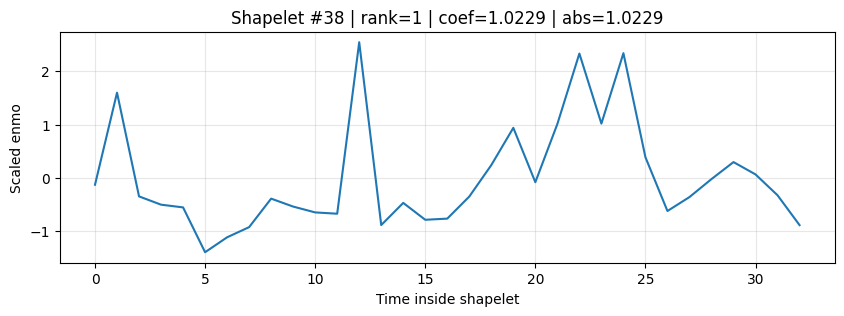

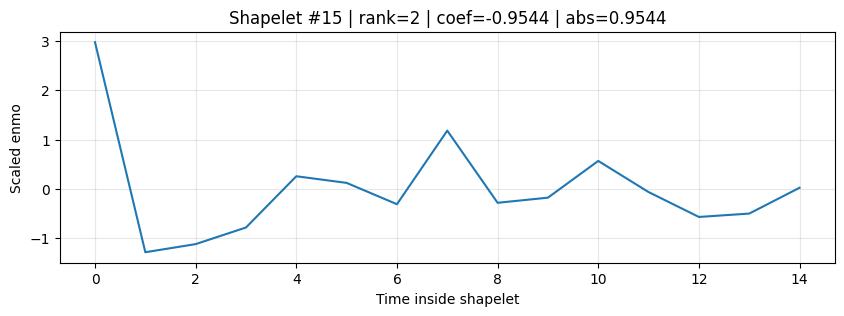

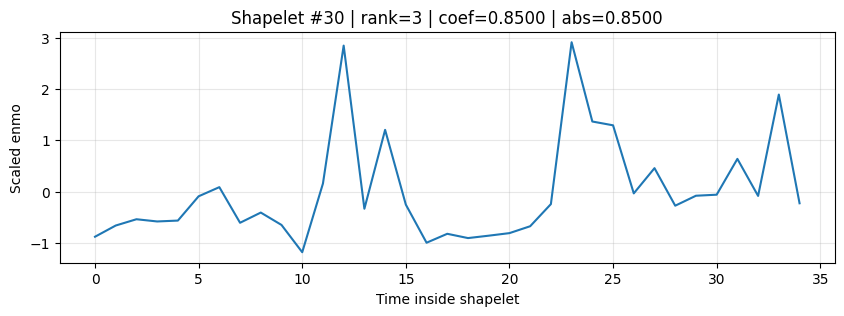

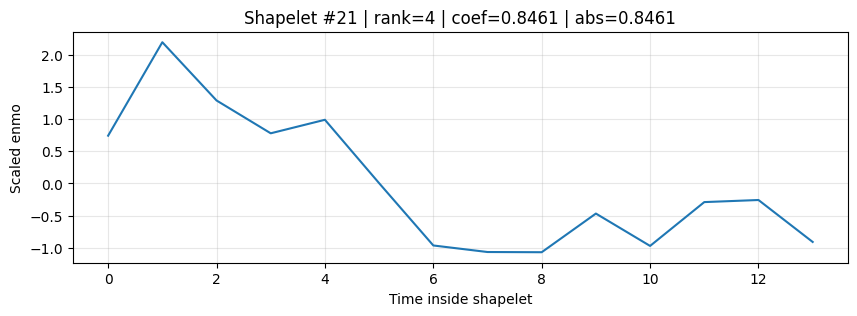

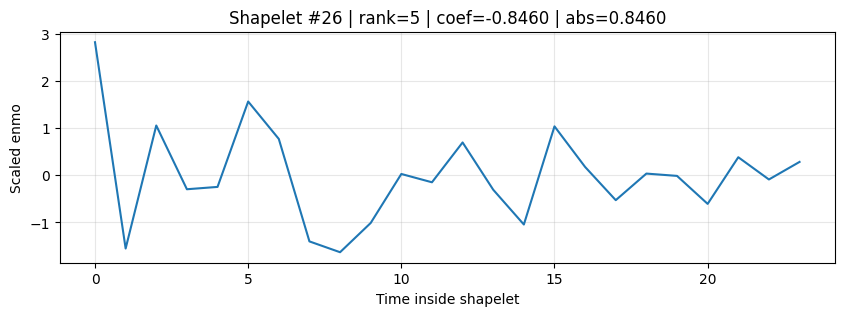


OGGETTI CREATI
shapelet_transform
X_train_shapelet_features, X_test_shapelet_features
clf_shapelet
y_test_pred_shapelet
test_results_shapelet
shapelet_importance_df
shapelets


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import subprocess

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# INSTALL / IMPORT SKTIME
# ============================================================

try:
    from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sktime"])
    from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform

# ============================================================
# SHAPELET-BASED CLASSIFICATION
# RandomShapeletTransform + LogisticRegression
# ============================================================

print("=" * 80)
print("SHAPELET-BASED CLASSIFICATION")
print("=" * 80)

RANDOM_STATE = 42

# ============================================================
# 1. Selezione del canale ENMO
# ============================================================

shapelet_channel = "enmo"
channel_idx = signal_cols.index(shapelet_channel)

X_train_enmo = X_train[:, :, channel_idx]
X_test_enmo = X_test[:, :, channel_idx]

print("\nCanale usato per shapelets:")
print(shapelet_channel)

print("\nShape prima del reshape:")
print("X_train_enmo:", X_train_enmo.shape)
print("X_test_enmo: ", X_test_enmo.shape)

# ============================================================
# 2. Scaling train-only sul canale ENMO
# ============================================================

scaler_enmo = StandardScaler()

scaler_enmo.fit(
    X_train_enmo.reshape(-1, 1)
)

X_train_enmo_scaled = scaler_enmo.transform(
    X_train_enmo.reshape(-1, 1)
).reshape(X_train_enmo.shape)

X_test_enmo_scaled = scaler_enmo.transform(
    X_test_enmo.reshape(-1, 1)
).reshape(X_test_enmo.shape)

# sktime vuole shape: (n_instances, n_channels, n_timepoints)
X_train_shapelet = X_train_enmo_scaled[:, np.newaxis, :]
X_test_shapelet = X_test_enmo_scaled[:, np.newaxis, :]

print("\nShape per sktime:")
print("X_train_shapelet:", X_train_shapelet.shape)
print("X_test_shapelet: ", X_test_shapelet.shape)

# ============================================================
# 3. Random Shapelet Transform
# ============================================================

shapelet_transform = RandomShapeletTransform(
    n_shapelet_samples=1000,
    max_shapelets=100,
    min_shapelet_length=6,
    max_shapelet_length=40,
    random_state=RANDOM_STATE,
    n_jobs=1
)

print("\nFitting RandomShapeletTransform...")

X_train_shapelet_features = shapelet_transform.fit_transform(
    X_train_shapelet,
    y_train
)

X_test_shapelet_features = shapelet_transform.transform(
    X_test_shapelet
)

print("\nShape dopo Shapelet Transform:")
print("X_train_shapelet_features:", X_train_shapelet_features.shape)
print("X_test_shapelet_features: ", X_test_shapelet_features.shape)

# ============================================================
# 4. Classificatore sulle feature shapelet
# ============================================================

clf_shapelet = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

clf_shapelet.fit(
    X_train_shapelet_features,
    y_train
)

y_test_pred_shapelet = clf_shapelet.predict(
    X_test_shapelet_features
)

# ============================================================
# 5. Valutazione
# ============================================================

print("\n" + "=" * 80)
print("TEST RESULTS - SHAPELET MODEL")
print("=" * 80)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred_shapelet,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    y_test_pred_shapelet,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
)

print("Confusion matrix:")
display(cm_df)

test_results_shapelet = pd.DataFrame([{
    "model": "RandomShapeletTransform_LogisticRegression",
    "channel": shapelet_channel,
    "n_shapelet_samples": 1000,
    "max_shapelets": 100,
    "min_shapelet_length": 6,
    "max_shapelet_length": 40,
    "test_accuracy": accuracy_score(y_test, y_test_pred_shapelet),
    "test_precision_macro": precision_score(y_test, y_test_pred_shapelet, average="macro", zero_division=0),
    "test_recall_macro": recall_score(y_test, y_test_pred_shapelet, average="macro", zero_division=0),
    "test_f1_macro": f1_score(y_test, y_test_pred_shapelet, average="macro", zero_division=0),
    "test_f1_weighted": f1_score(y_test, y_test_pred_shapelet, average="weighted", zero_division=0)
}])

print("\nTabella risultati:")
display(test_results_shapelet)

# ============================================================
# 6. Recupero shapelets
# ============================================================

if hasattr(shapelet_transform, "shapelets"):
    shapelets = shapelet_transform.shapelets
elif hasattr(shapelet_transform, "shapelets_"):
    shapelets = shapelet_transform.shapelets_
else:
    raise AttributeError("Non trovo shapelets o shapelets_ nell'oggetto transform.")

print("\nNumero shapelets recuperate:")
print(len(shapelets))

# ============================================================
# 7. Importanza shapelets tramite coefficienti Logistic Regression
# ============================================================

coefs = clf_shapelet.coef_[0]
importance = np.abs(coefs)

top_idx = np.argsort(importance)[::-1]

shapelet_importance_df = pd.DataFrame({
    "shapelet_index": np.arange(len(coefs)),
    "coefficient": coefs,
    "abs_coefficient": importance
}).sort_values("abs_coefficient", ascending=False)

print("\nShapelets ordinate per importanza nel classificatore:")
display(shapelet_importance_df)

# ============================================================
# 8. Funzione robusta per estrarre valori shapelet
# ============================================================

def get_shapelet_values(shapelet_obj):
    """
    Estrae i valori numerici della shapelet.
    Compatibile con diverse versioni di sktime.
    """

    if hasattr(shapelet_obj, "values"):
        return np.asarray(shapelet_obj.values)

    if isinstance(shapelet_obj, tuple) or isinstance(shapelet_obj, list):
        # Nel laboratorio spesso i valori sono nell'ultimo elemento
        for element in reversed(shapelet_obj):
            arr = np.asarray(element)
            if arr.ndim >= 1 and np.issubdtype(arr.dtype, np.number):
                return arr

    arr = np.asarray(shapelet_obj)

    if arr.ndim >= 1 and np.issubdtype(arr.dtype, np.number):
        return arr

    raise ValueError("Non riesco a estrarre i valori della shapelet.")

# ============================================================
# 9. Plot delle shapelets più importanti
# ============================================================

n_top_shapelets = min(5, len(shapelets))

print("\nPlot delle shapelets più importanti:")

for rank, shp_idx in enumerate(top_idx[:n_top_shapelets], start=1):

    shp_values = get_shapelet_values(shapelets[shp_idx]).ravel()

    plt.figure(figsize=(10, 3))
    plt.plot(shp_values)
    plt.title(
        f"Shapelet #{shp_idx} | rank={rank} | "
        f"coef={coefs[shp_idx]:.4f} | abs={importance[shp_idx]:.4f}"
    )
    plt.xlabel("Time inside shapelet")
    plt.ylabel("Scaled enmo")
    plt.grid(alpha=0.3)
    plt.show()

# ============================================================
# 10. Oggetti creati
# ============================================================

print("\n" + "=" * 80)
print("OGGETTI CREATI")
print("=" * 80)

print("shapelet_transform")
print("X_train_shapelet_features, X_test_shapelet_features")
print("clf_shapelet")
print("y_test_pred_shapelet")
print("test_results_shapelet")
print("shapelet_importance_df")
print("shapelets")

## 9. Build and save metadata for the 100 retrieved shapelets

In [12]:
coefs = clf_shapelet.coef_.ravel()
if len(coefs) != len(shapelets):
    raise ValueError(f"{len(coefs)} LR coefficients but {len(shapelets)} shapelets.")

shapelet_records = []

for shapelet_index, shapelet in enumerate(shapelets):
    information_gain = float(shapelet[0])
    shapelet_length = int(shapelet[1])
    shapelet_start = int(shapelet[2])
    shapelet_dimension = int(shapelet[3])
    train_series_index = int(shapelet[4])
    shapelet_class = int(shapelet[5])
    shapelet_values = np.asarray(shapelet[6],dtype=float).ravel()

    global_ts_index = int(train_global_indices[train_series_index])
    source_ts = df[global_ts_index]

    shapelet_records.append({
        "shapelet_index":shapelet_index,
        "train_series_index":train_series_index,
        "ts_index":global_ts_index,
        "id":source_ts["id"].iloc[0],
        "target":int(source_ts["sii_binary"].iloc[0]),
        "shapelet_class":shapelet_class,
        "shapelet_dimension":shapelet_dimension,
        "shapelet_start":shapelet_start,
        "shapelet_end":shapelet_start+shapelet_length,
        "shapelet_length":shapelet_length,
        "information_gain":information_gain,
        "lr_coefficient":float(coefs[shapelet_index]),
        "abs_lr_coefficient":float(abs(coefs[shapelet_index])),
        "shapelet_values":shapelet_values,
    })

shapelet_metadata_all = (
    pd.DataFrame(shapelet_records)
    .sort_values("abs_lr_coefficient",ascending=False)
    .reset_index(drop=True)
)

shapelet_metadata_top10 = shapelet_metadata_all.head(10).copy()

display(
    shapelet_metadata_top10[
        ["shapelet_index","ts_index","id","target","shapelet_length",
         "information_gain","lr_coefficient","abs_lr_coefficient"]
    ]
)

shapelet_metadata_all.to_pickle(CLASS_DIR/"shapelet_metadata_all.pkl")
shapelet_metadata_top10.to_pickle(CLASS_DIR/"shapelet_metadata_top10.pkl")

csv_copy = shapelet_metadata_top10.drop(columns=["shapelet_values"]).copy()
csv_copy.to_csv(CLASS_DIR/"shapelet_metadata_top10.csv",index=False)

print("Saved shapelet metadata.")

,shapelet_index,ts_index,id,target,shapelet_length,information_gain,lr_coefficient,abs_lr_coefficient
0,38,244,1056,0,33,0.004286,1.022874,1.022874
1,15,388,2473,0,15,0.005739,-0.954442,0.954442
2,30,1289,1647,1,35,0.004771,0.850050,0.850050
3,21,301,1592,1,14,0.005532,0.846139,0.846139
4,26,868,3570,0,24,0.005121,-0.845975,0.845975
5,41,1350,735,0,15,0.004217,-0.791571,0.791571
6,49,701,68,0,12,0.003966,0.787662,0.787662
7,92,807,1728,1,23,0.002838,-0.773508,0.773508
8,0,735,1262,1,23,0.008925,0.770118,0.770118
9,59,1405,777,1,15,0.003752,-0.755225,0.755225


Saved shapelet metadata.


## 10. Multivariate ShapeletTransformClassifier — PAA 50, max 10

In [13]:
import numpy as np
import pandas as pd
import sys
import subprocess
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# INSTALLAZIONE / IMPORT DELLE LIBRERIE
# ============================================================

try:
    from sktime.classification.shapelet_based import (
        ShapeletTransformClassifier
    )
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "sktime"
    ])

    from sktime.classification.shapelet_based import (
        ShapeletTransformClassifier
    )


try:
    from tslearn.piecewise import PiecewiseAggregateApproximation
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "tslearn"
    ])

    from tslearn.piecewise import PiecewiseAggregateApproximation


# ============================================================
# CONFIGURAZIONE
# ============================================================

RANDOM_STATE = 42
N_PAA_SEGMENTS = 50

# Numero di shapelet candidate da esaminare.
# 200 è molto più rapido di 1000.
N_SHAPELET_SAMPLES = 200

# Numero massimo di shapelet conservate.
MAX_SHAPELETS = 10

SHAPELET_CHANNELS = [
    "X",
    "Y",
    "Z",
    "enmo",
    "light"
]


print("=" * 80)
print("MULTIVARIATE SHAPELET TRANSFORM CLASSIFIER")
print("PAA CON 50 SEGMENTI")
print("=" * 80)


# ============================================================
# 1. CONTROLLO DELLE VARIABILI NECESSARIE
# ============================================================

required_variables = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "signal_cols"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Mancano le seguenti variabili: "
        + ", ".join(missing_variables)
    )


X_train = np.asarray(X_train)
X_test = np.asarray(X_test)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)


if X_train.ndim != 3 or X_test.ndim != 3:
    raise ValueError(
        "X_train e X_test devono avere formato "
        "(n_series, n_time_steps, n_channels)."
    )


print("\nShape iniziali:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

print("\nFormato iniziale:")
print("(n_series, n_time_steps, n_channels)")

print("\nColonne disponibili:")
print(signal_cols)


# ============================================================
# 2. SELEZIONE DEI CINQUE CANALI
# ============================================================

# Ricerca case-insensitive, così funzionano sia X/Y/Z
# sia x/y/z.
signal_cols_lower = [
    str(column).lower()
    for column in signal_cols
]

requested_channels_lower = [
    channel.lower()
    for channel in SHAPELET_CHANNELS
]

missing_channels = [
    channel
    for channel in requested_channels_lower
    if channel not in signal_cols_lower
]

if missing_channels:
    raise ValueError(
        "Non sono stati trovati i seguenti canali: "
        + ", ".join(missing_channels)
        + "\nCanali presenti: "
        + str(signal_cols)
    )


channel_indices = [
    signal_cols_lower.index(channel)
    for channel in requested_channels_lower
]

actual_channel_names = [
    signal_cols[index]
    for index in channel_indices
]

X_train_shapelet_raw = X_train[:, :, channel_indices].copy()
X_test_shapelet_raw = X_test[:, :, channel_indices].copy()


print("\nCanali utilizzati:")
print(actual_channel_names)

print("\nShape dopo la selezione dei canali:")
print("X_train_shapelet_raw:", X_train_shapelet_raw.shape)
print("X_test_shapelet_raw: ", X_test_shapelet_raw.shape)


# ============================================================
# 3. CONTROLLO NaN E VALORI INFINITI
# ============================================================

if not np.isfinite(X_train_shapelet_raw).all():
    raise ValueError(
        "X_train contiene NaN o valori infiniti."
    )

if not np.isfinite(X_test_shapelet_raw).all():
    raise ValueError(
        "X_test contiene NaN o valori infiniti."
    )


# ============================================================
# 4. STANDARDIZZAZIONE TRAIN-ONLY
# ============================================================

n_train, n_time_steps, n_channels = (
    X_train_shapelet_raw.shape
)

n_test = X_test_shapelet_raw.shape[0]


# Trasformazione temporanea:
#
# (n_series, n_time_steps, n_channels)
#                ↓
# (n_series * n_time_steps, n_channels)
#
# Ogni canale viene standardizzato separatamente.

X_train_shapelet_2d = X_train_shapelet_raw.reshape(
    -1,
    n_channels
)

X_test_shapelet_2d = X_test_shapelet_raw.reshape(
    -1,
    n_channels
)


scaler_shapelet_multivariate = StandardScaler()

# Il fit viene eseguito esclusivamente sul train.
X_train_shapelet_scaled_2d = (
    scaler_shapelet_multivariate.fit_transform(
        X_train_shapelet_2d
    )
)

X_test_shapelet_scaled_2d = (
    scaler_shapelet_multivariate.transform(
        X_test_shapelet_2d
    )
)


X_train_shapelet_scaled = (
    X_train_shapelet_scaled_2d.reshape(
        n_train,
        n_time_steps,
        n_channels
    )
)

X_test_shapelet_scaled = (
    X_test_shapelet_scaled_2d.reshape(
        n_test,
        n_time_steps,
        n_channels
    )
)


print("\nShape dopo lo scaling:")
print("Train:", X_train_shapelet_scaled.shape)
print("Test: ", X_test_shapelet_scaled.shape)


# ============================================================
# 5. PIECEWISE AGGREGATE APPROXIMATION
# ============================================================

if n_time_steps < N_PAA_SEGMENTS:
    raise ValueError(
        f"Le serie hanno {n_time_steps} time step, "
        f"quindi non possono essere ridotte a "
        f"{N_PAA_SEGMENTS} segmenti."
    )


paa_shapelet = PiecewiseAggregateApproximation(
    n_segments=N_PAA_SEGMENTS
)


# tslearn mantiene il formato:
# (n_series, n_time_steps, n_channels)
#
# Dopo il PAA:
# (n_series, 50, n_channels)

X_train_shapelet_paa = paa_shapelet.fit_transform(
    X_train_shapelet_scaled
)

X_test_shapelet_paa = paa_shapelet.transform(
    X_test_shapelet_scaled
)


print("\nPAA completata:")
print("Numero segmenti PAA:", N_PAA_SEGMENTS)

print("\nShape prima del PAA:")
print("Train:", X_train_shapelet_scaled.shape)
print("Test: ", X_test_shapelet_scaled.shape)

print("\nShape dopo il PAA:")
print("Train:", X_train_shapelet_paa.shape)
print("Test: ", X_test_shapelet_paa.shape)


assert X_train_shapelet_paa.shape[1] == N_PAA_SEGMENTS
assert X_test_shapelet_paa.shape[1] == N_PAA_SEGMENTS


# ============================================================
# 6. CONVERSIONE NEL FORMATO RICHIESTO DA SKTIME
# ============================================================

# Formato tslearn:
# (n_series, n_time_steps, n_channels)
#
# Formato sktime:
# (n_series, n_channels, n_time_steps)

X_train_stc_multivariate = np.transpose(
    X_train_shapelet_paa,
    (0, 2, 1)
)

X_test_stc_multivariate = np.transpose(
    X_test_shapelet_paa,
    (0, 2, 1)
)


print("\nShape finale per sktime:")
print(
    "X_train_stc_multivariate:",
    X_train_stc_multivariate.shape
)
print(
    "X_test_stc_multivariate: ",
    X_test_stc_multivariate.shape
)

print("\nFormato finale:")
print("(n_series, n_channels, n_time_steps)")


assert X_train_stc_multivariate.shape[1] == 5
assert X_train_stc_multivariate.shape[2] == 50

assert X_test_stc_multivariate.shape[1] == 5
assert X_test_stc_multivariate.shape[2] == 50


if not np.isfinite(X_train_stc_multivariate).all():
    raise ValueError(
        "Il train trasformato contiene NaN o infiniti."
    )

if not np.isfinite(X_test_stc_multivariate).all():
    raise ValueError(
        "Il test trasformato contiene NaN o infiniti."
    )


# ============================================================
# 7. SHAPELET TRANSFORM CLASSIFIER MULTIVARIATO
# ============================================================

# Dopo il PAA le serie hanno soltanto 50 punti.
# Limitiamo la lunghezza massima delle shapelet a 25 punti.

MAX_SHAPELET_LENGTH = 25


stc_multivariate_paa50 = ShapeletTransformClassifier(
    n_shapelet_samples=N_SHAPELET_SAMPLES,
    max_shapelets=MAX_SHAPELETS,
    max_shapelet_length=MAX_SHAPELET_LENGTH,
    random_state=RANDOM_STATE,
    n_jobs=1
)


print("\n" + "=" * 80)
print("ADDESTRAMENTO DEL MODELLO")
print("=" * 80)

print("Canali:", actual_channel_names)
print("Segmenti PAA:", N_PAA_SEGMENTS)
print("Shapelet candidate:", N_SHAPELET_SAMPLES)
print("Shapelet conservate:", MAX_SHAPELETS)
print("Lunghezza massima shapelet:", MAX_SHAPELET_LENGTH)


start_time = time.perf_counter()

stc_multivariate_paa50.fit(
    X_train_stc_multivariate,
    y_train
)

training_time_seconds = (
    time.perf_counter() - start_time
)


print(
    "\nTempo di addestramento:",
    round(training_time_seconds, 2),
    "secondi"
)


# ============================================================
# 8. PREDIZIONE SUL TEST
# ============================================================

prediction_start_time = time.perf_counter()

y_test_pred_stc_multivariate_paa50 = (
    stc_multivariate_paa50.predict(
        X_test_stc_multivariate
    )
)

prediction_time_seconds = (
    time.perf_counter() - prediction_start_time
)


print(
    "Tempo di predizione:",
    round(prediction_time_seconds, 2),
    "secondi"
)


# ============================================================
# 9. METRICHE DI VALUTAZIONE
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred_stc_multivariate_paa50
)

test_precision_macro = precision_score(
    y_test,
    y_test_pred_stc_multivariate_paa50,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    y_test,
    y_test_pred_stc_multivariate_paa50,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    y_test,
    y_test_pred_stc_multivariate_paa50,
    average="macro",
    zero_division=0
)

test_f1_weighted = f1_score(
    y_test,
    y_test_pred_stc_multivariate_paa50,
    average="weighted",
    zero_division=0
)


print("\n" + "=" * 80)
print("TEST RESULTS")
print("MULTIVARIATE SHAPELET + PAA 50")
print("=" * 80)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred_stc_multivariate_paa50,
        zero_division=0
    )
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

class_labels = np.unique(
    np.concatenate([
        y_train,
        y_test
    ])
)

cm_stc_multivariate_paa50 = confusion_matrix(
    y_test,
    y_test_pred_stc_multivariate_paa50,
    labels=class_labels
)

cm_stc_multivariate_paa50_df = pd.DataFrame(
    cm_stc_multivariate_paa50,
    index=[
        f"true_{label}"
        for label in class_labels
    ],
    columns=[
        f"pred_{label}"
        for label in class_labels
    ]
)


print("Confusion matrix:")
display(cm_stc_multivariate_paa50_df)


# ============================================================
# 11. TABELLA RIASSUNTIVA
# ============================================================

test_results_stc_multivariate_paa50 = pd.DataFrame([{
    "model": (
        "Multivariate_ShapeletTransformClassifier_PAA50"
    ),
    "channels": ", ".join(
        map(str, actual_channel_names)
    ),
    "n_channels": len(actual_channel_names),
    "original_time_steps": n_time_steps,
    "paa_segments": N_PAA_SEGMENTS,
    "n_shapelet_samples": N_SHAPELET_SAMPLES,
    "max_shapelets": MAX_SHAPELETS,
    "max_shapelet_length": MAX_SHAPELET_LENGTH,
    "training_time_seconds": training_time_seconds,
    "prediction_time_seconds": prediction_time_seconds,
    "test_accuracy": test_accuracy,
    "test_precision_macro": test_precision_macro,
    "test_recall_macro": test_recall_macro,
    "test_f1_macro": test_f1_macro,
    "test_f1_weighted": test_f1_weighted
}])


print("\nTabella risultati:")
display(test_results_stc_multivariate_paa50)


# ============================================================
# 12. RISULTATI PRINCIPALI
# ============================================================

print("\n" + "=" * 80)
print("RISULTATI PRINCIPALI")
print("=" * 80)

print(
    "Test accuracy:",
    round(test_accuracy, 4)
)

print(
    "Test precision macro:",
    round(test_precision_macro, 4)
)

print(
    "Test recall macro:",
    round(test_recall_macro, 4)
)

print(
    "Test F1 macro:",
    round(test_f1_macro, 4)
)

print(
    "Test F1 weighted:",
    round(test_f1_weighted, 4)
)


# ============================================================
# 13. OGGETTI CREATI
# ============================================================

print("\n" + "=" * 80)
print("OGGETTI CREATI")
print("=" * 80)

print("scaler_shapelet_multivariate")
print("paa_shapelet")
print("X_train_shapelet_paa")
print("X_test_shapelet_paa")
print("X_train_stc_multivariate")
print("X_test_stc_multivariate")
print("stc_multivariate_paa50")
print("y_test_pred_stc_multivariate_paa50")
print("test_results_stc_multivariate_paa50")

/Users/sarabiiavasco/Codice/venv/lib/python3.13/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


MULTIVARIATE SHAPELET TRANSFORM CLASSIFIER
PAA CON 50 SEGMENTI

Shape iniziali:
X_train: (3106, 200, 5)
X_test:  (1152, 200, 5)

Formato iniziale:
(n_series, n_time_steps, n_channels)

Colonne disponibili:
['X', 'Y', 'Z', 'enmo', 'light']

Canali utilizzati:
['X', 'Y', 'Z', 'enmo', 'light']

Shape dopo la selezione dei canali:
X_train_shapelet_raw: (3106, 200, 5)
X_test_shapelet_raw:  (1152, 200, 5)

Shape dopo lo scaling:
Train: (3106, 200, 5)
Test:  (1152, 200, 5)

PAA completata:
Numero segmenti PAA: 50

Shape prima del PAA:
Train: (3106, 200, 5)
Test:  (1152, 200, 5)

Shape dopo il PAA:
Train: (3106, 50, 5)
Test:  (1152, 50, 5)

Shape finale per sktime:
X_train_stc_multivariate: (3106, 5, 50)
X_test_stc_multivariate:  (1152, 5, 50)

Formato finale:
(n_series, n_channels, n_time_steps)

ADDESTRAMENTO DEL MODELLO
Canali: ['X', 'Y', 'Z', 'enmo', 'light']
Segmenti PAA: 50
Shapelet candidate: 200
Shapelet conservate: 10
Lunghezza massima shapelet: 25

Tempo di addestramento: 201.24 seco

,pred_0,pred_1
true_0,734,86
true_1,285,47



Tabella risultati:


,model,channels,n_channels,original_time_steps,paa_segments,n_shapelet_samples,max_shapelets,max_shapelet_length,training_time_seconds,prediction_time_seconds,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
0,Multivariate_ShapeletTransformClassifier_PAA50,"X, Y, Z, enmo, light",5,200,50,200,10,25,201.236925,0.179364,0.677951,0.536849,0.518344,0.500205,0.626465



RISULTATI PRINCIPALI
Test accuracy: 0.678
Test precision macro: 0.5368
Test recall macro: 0.5183
Test F1 macro: 0.5002
Test F1 weighted: 0.6265

OGGETTI CREATI
scaler_shapelet_multivariate
paa_shapelet
X_train_shapelet_paa
X_test_shapelet_paa
X_train_stc_multivariate
X_test_stc_multivariate
stc_multivariate_paa50
y_test_pred_stc_multivariate_paa50
test_results_stc_multivariate_paa50


## 11. ROC/AUC for the selected models

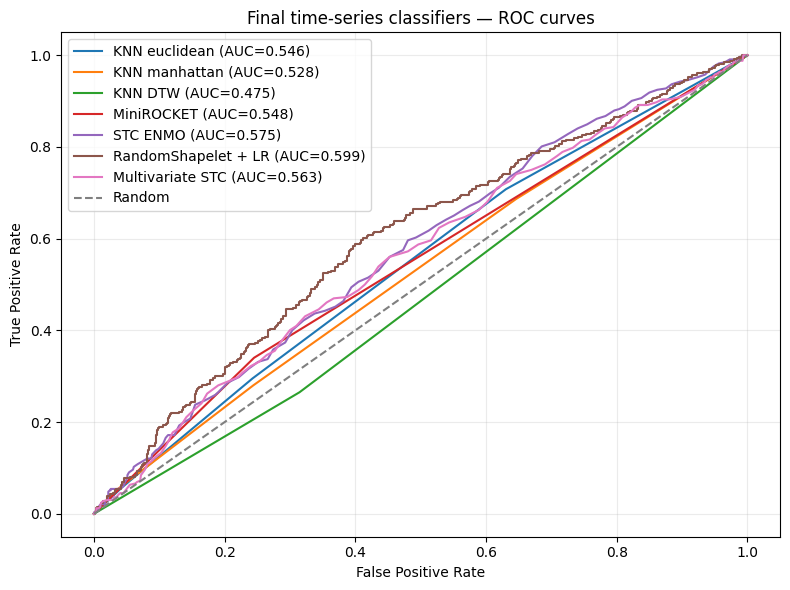

,model,auc
5,RandomShapelet + LR,0.599254
4,STC ENMO,0.575329
6,Multivariate STC,0.563409
3,MiniROCKET,0.547620
0,KNN euclidean,0.546481
1,KNN manhattan,0.528468
2,KNN DTW,0.475213


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

roc_rows = []

def add_roc(name, scores):
    auc = roc_auc_score(y_test,scores)
    fpr,tpr,_ = roc_curve(y_test,scores)
    roc_rows.append({"model":name,"auc":auc})
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")

plt.figure(figsize=(8,6))

for metric in ["euclidean","manhattan"]:
    add_roc(f"KNN {metric}",knn_probabilities[metric])

# DTW continuous class-1 score using the selected neighbors.
def dtw_positive_score(D, y_train_fold, k, weights):
    nearest_idx = np.argsort(D,axis=1)[:,:k]
    nearest_labels = y_train_fold[nearest_idx]
    nearest_dist = np.take_along_axis(D,nearest_idx,axis=1)
    scores = []
    for labels_i,dist_i in zip(nearest_labels,nearest_dist):
        if weights == "uniform":
            scores.append(float(np.mean(labels_i == 1)))
        else:
            wgt = 1.0/(dist_i+1e-12)
            scores.append(float(wgt[labels_i==1].sum()/wgt.sum()))
    return np.array(scores)

dtw_score = dtw_positive_score(D_test_train,y_train,best_k,best_weights)
add_roc("KNN DTW",dtw_score)

try:
    mini_score = minirocket_clf.predict_proba(X_test_minirocket)[:,1]
    add_roc("MiniROCKET",mini_score)
except Exception:
    print("MiniROCKET predict_proba unavailable; ROC skipped.")

stc_score = stc.predict_proba(X_test_stc)[:,np.where(stc.classes_==1)[0][0]]
add_roc("STC ENMO",stc_score)

rst_score = clf_shapelet.predict_proba(X_test_shapelet_features)[:,1]
add_roc("RandomShapelet + LR",rst_score)

multi_score = stc_multivariate_paa50.predict_proba(X_test_stc_multivariate)[:,np.where(stc_multivariate_paa50.classes_==1)[0][0]]
add_roc("Multivariate STC",multi_score)

plt.plot([0,1],[0,1],"--",label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Final time-series classifiers — ROC curves")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

roc_df = pd.DataFrame(roc_rows).sort_values("auc",ascending=False)
display(roc_df)
roc_df.to_csv(CLASS_DIR/"ROC_AUC_final_timeseries_models.csv",index=False)

## 12. Final comparison

In [15]:
result_frames = [
    test_results_df,
    test_results_dtw,
    test_results_minirocket,
    test_results_stc,
    test_results_shapelet,
    test_results_stc_multivariate_paa50,
]

final_results = pd.concat(result_frames,ignore_index=True,sort=False)
display(
    final_results[
        ["model","test_accuracy","test_precision_macro","test_recall_macro",
         "test_f1_macro","test_f1_weighted"]
    ].sort_values("test_f1_macro",ascending=False).round(4)
)

final_results.to_csv(CLASS_DIR/"classification_results_final.csv",index=False)

,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
5,RandomShapeletTransform_LogisticRegression,0.6068,0.5705,0.5831,0.5670,0.6226
3,MiniROCKET,0.6354,0.5493,0.5476,0.5483,0.6323
0,KNN_euclidean_uniform,0.6241,0.5281,0.5262,0.5265,0.6176
1,KNN_manhattan_uniform,0.6189,0.5196,0.5181,0.5181,0.6115
4,ShapeletTransformClassifier,0.6823,0.5432,0.5205,0.5013,0.6286
6,Multivariate_ShapeletTransformClassifier_PAA50,0.6780,0.5368,0.5183,0.5002,0.6265
2,KNN_DTW,0.5642,0.4758,0.4752,0.4754,0.5669


## 13. Historical discarded benchmarks

These were evaluated during development but are not rerun because they were not selected:

| Experiment | Accuracy | Macro F1 | Decision |
|---|---:|---:|---|
| Standard ROCKET, 10k | ~0.602 | ~0.517 | worse than MiniROCKET |
| MiniROCKET, 100k | ~0.612 | ~0.538 | worse than 10k |
| STC ENMO, max 100 | ~0.697 | ~0.487 | worse macro-F1 than max 10 |
| RandomShapelet+LR, max 10 | ~0.592 | ~0.553 | worse than max 100 |
| Multivariate STC PAA50, max 100 | ~0.700 | ~0.457 | worse macro-F1 than max 10 |

The selected `RandomShapeletTransform + LogisticRegression` with 100 retained shapelets is used in notebook 05 for the final motif/discord comparison.

## 14. Save selected reusable objects

In [16]:
import joblib

joblib.dump(final_scaler, CLASS_DIR/"knn_euclidean_manhattan_scaler.joblib")
joblib.dump(knn_models, CLASS_DIR/"knn_euclidean_manhattan_models.joblib")
joblib.dump(scaler_enmo, CLASS_DIR/"random_shapelet_enmo_scaler.joblib")
joblib.dump(shapelet_transform, CLASS_DIR/"random_shapelet_transform.joblib")
joblib.dump(clf_shapelet, CLASS_DIR/"random_shapelet_logistic_regression.joblib")

print("Reusable classification artifacts saved in:",CLASS_DIR)

Reusable classification artifacts saved in: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module3/classification
